# 03. Retail margins and pass-through using ENSE reference prices
The ENSE reference price includes international quotes for refined products, biofuels, logistics and taxes, but not retail costs and margin.
Comparing it with the pump price shows the retail margin, and tests whether petrol stations pass on cost changes asymmetrically.

In [1]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
# Load the ENSE daily reference prices (separated by ";" with "," as decimal)
gasoline_ref = pd.read_csv("../data/raw/ense_reference_gasoline.csv", sep=";", decimal=",", encoding="utf-8-sig")
diesel_ref = pd.read_csv("../data/raw/ense_reference_diesel.csv", sep=";", decimal=",", encoding="utf-8-sig")

# Keep the date and the daily reference price, with simple names
gasoline_ref = gasoline_ref.rename(columns={"DATA": "date", "PR diario da Gasolina": "gasoline_ref"})
gasoline_ref = gasoline_ref[["date", "gasoline_ref"]]
diesel_ref = diesel_ref.rename(columns={"DATA": "date", "PR diario do Gasoleo": "diesel_ref"})
diesel_ref = diesel_ref[["date", "diesel_ref"]]

# Merge both fuels and turn the date into a real date (day first, Portuguese format)
ref = pd.merge(gasoline_ref, diesel_ref, on="date")
ref["date"] = pd.to_datetime(ref["date"], dayfirst=True)
print(len(ref), "days of reference prices")
ref.tail()

2006 days of reference prices


,date,gasoline_ref,diesel_ref
2001,2026-09-22,1.891,1.949
2002,2026-09-23,1.898,1.931
2003,2026-09-24,1.913,1.973
2004,2026-09-25,1.965,2.006
2005,2026-09-28,1.921,1.966


In [3]:
# Weekly averages, moved to the next Monday (pump prices on Monday reflect last week's costs)
ref_weekly = ref.resample("W", on="date").mean()
ref_weekly = ref_weekly.reset_index()
ref_weekly["date"] = ref_weekly["date"] + pd.Timedelta(days=1)

# Merge with the weekly pump prices from notebook 02
fuel = pd.read_csv("../data/processed/fuel_prices_pt.csv", parse_dates=["date"])
df = pd.merge(fuel, ref_weekly, on="date")

# Retail margin = pump price minus reference price
df["gasoline_retail_margin"] = df["gasoline_with_tax"] - df["gasoline_ref"]
df["diesel_retail_margin"] = df["diesel_with_tax"] - df["diesel_ref"]
df.to_csv("../data/processed/ense_retail_margins.csv", index=False)

print(len(df), "weeks")
df[["gasoline_retail_margin", "diesel_retail_margin"]].mean()

395 weeks


gasoline_retail_margin    0.197473
diesel_retail_margin      0.172955
dtype: float64

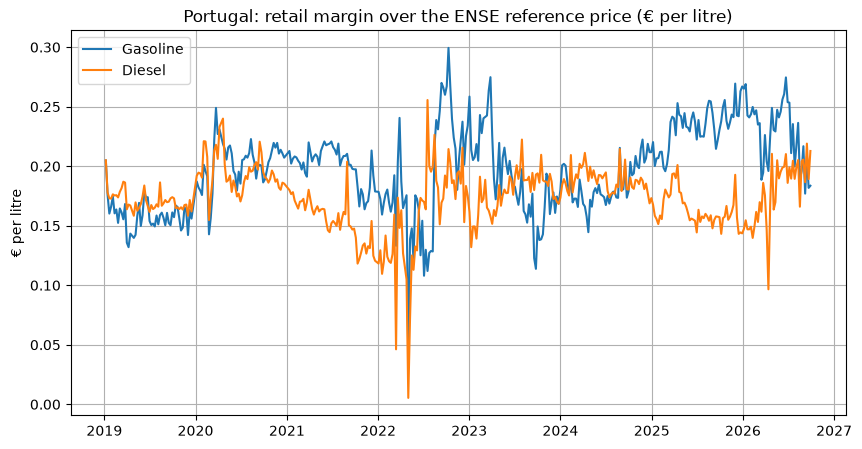

In [4]:
# Plot the retail margins over time
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["gasoline_retail_margin"], label="Gasoline")
plt.plot(df["date"], df["diesel_retail_margin"], label="Diesel")
plt.title("Portugal: retail margin over the ENSE reference price (€ per litre)")
plt.ylabel("€ per litre")
plt.legend()
plt.grid(True)

# Save and show the chart
plt.savefig("../figures/retail_margins.png")
plt.show()

In [5]:
# Run the improved model for each fuel, using the reference price as the cost
ense_results = []

for fuel_name in ["gasoline", "diesel"]:
    # Weekly change in the reference price, split into rises and falls
    d_ref = df[f"{fuel_name}_ref"].diff()
    df["ref_up"] = d_ref.clip(lower=0)
    df["ref_down"] = d_ref.clip(upper=0)

    # The same changes in the previous three weeks
    for lag in [1, 2, 3]:
        df[f"ref_up_lag{lag}"] = df["ref_up"].shift(lag)
        df[f"ref_down_lag{lag}"] = df["ref_down"].shift(lag)

    # Weekly change in the pump price and last week's change (momentum)
    df["d_pump"] = df[f"{fuel_name}_with_tax"].diff()
    df["d_pump_lag1"] = df["d_pump"].shift(1)

    # Regression with HAC standard errors
    formula = "d_pump ~ ref_up + ref_up_lag1 + ref_up_lag2 + ref_up_lag3 + ref_down + ref_down_lag1 + ref_down_lag2 + ref_down_lag3 + d_pump_lag1"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Long run pass-through of rises and falls
    momentum = model.params["d_pump_lag1"]
    long_run_up = model.params[["ref_up", "ref_up_lag1", "ref_up_lag2", "ref_up_lag3"]].sum() / (1 - momentum)
    long_run_down = model.params[["ref_down", "ref_down_lag1", "ref_down_lag2", "ref_down_lag3"]].sum() / (1 - momentum)

    # Test if rises and falls are passed through equally
    test = model.f_test("ref_up + ref_up_lag1 + ref_up_lag2 + ref_up_lag3 = ref_down + ref_down_lag1 + ref_down_lag2 + ref_down_lag3")

    ense_results.append({
        "fuel": fuel_name,
        "long_run_rises": round(long_run_up, 2),
        "long_run_falls": round(long_run_down, 2),
        "p_value_HAC": round(float(test.pvalue), 3),
    })

# Show and save the results
ense_results = pd.DataFrame(ense_results)
ense_results.to_csv("../data/processed/rockets_feathers_ense.csv", index=False)
ense_results

,fuel,long_run_rises,long_run_falls,p_value_HAC
0,gasoline,0.78,0.78,0.999
1,diesel,0.90,0.85,0.368


## Comparison: pass-through against Brent and against the ENSE reference price

In [6]:
# Combine the Brent results (notebook 02) and the ENSE results in one table
brent_results = pd.read_csv("../data/processed/rockets_feathers_improved.csv")
brent_results["cost"] = "Brent"
ense_results["cost"] = "ENSE reference"
comparison = pd.concat([brent_results, ense_results])

# Save it (also used by the Tableau dashboard)
comparison.to_csv("../data/processed/rockets_feathers_comparison.csv", index=False)
comparison

,fuel,long_run_rises,long_run_falls,p_value_HAC,cost
0,gasoline,0.88,0.84,0.863,Brent
1,diesel,1.34,0.80,0.047,Brent
0,gasoline,0.78,0.78,0.999,ENSE reference
1,diesel,0.90,0.85,0.368,ENSE reference


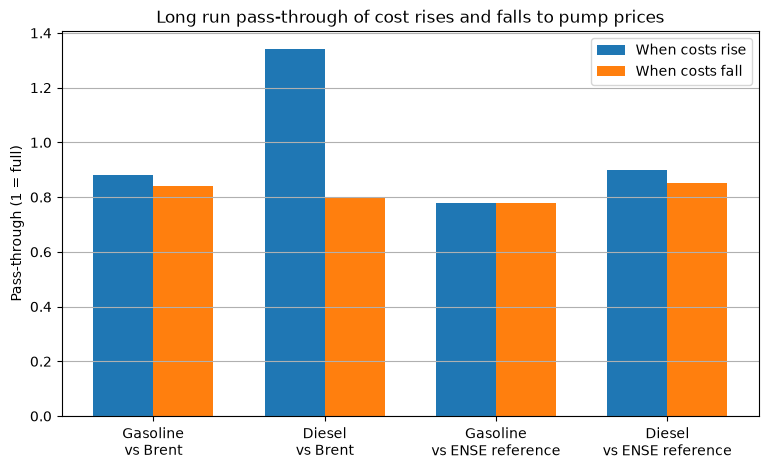

In [7]:
# Labels for each bar group, e.g. "Diesel vs Brent"
labels = (comparison["fuel"].str.capitalize() + "\nvs " + comparison["cost"]).tolist()
x = range(len(comparison))
width = 0.35

# Bar chart: long run pass-through of rises and falls
plt.figure(figsize=(9, 5))
plt.bar([i - width / 2 for i in x], comparison["long_run_rises"], width, label="When costs rise")
plt.bar([i + width / 2 for i in x], comparison["long_run_falls"], width, label="When costs fall")
plt.xticks(list(x), labels)
plt.title("Long run pass-through of cost rises and falls to pump prices")
plt.ylabel("Pass-through (1 = full)")
plt.legend()
plt.grid(True, axis="y")

# Save and show the chart
plt.savefig("../figures/rockets_feathers_comparison.png")
plt.show()

In [8]:
# Full regression tables of the improved model against the ENSE reference price (HAC standard errors)
for fuel_name in ["gasoline", "diesel"]:
    # Rebuild the variables for this fuel
    d_ref = df[f"{fuel_name}_ref"].diff()
    df["ref_up"] = d_ref.clip(lower=0)
    df["ref_down"] = d_ref.clip(upper=0)
    for lag in [1, 2, 3]:
        df[f"ref_up_lag{lag}"] = df["ref_up"].shift(lag)
        df[f"ref_down_lag{lag}"] = df["ref_down"].shift(lag)
    df["d_pump"] = df[f"{fuel_name}_with_tax"].diff()
    df["d_pump_lag1"] = df["d_pump"].shift(1)

    # Regression and symmetry test
    formula = "d_pump ~ ref_up + ref_up_lag1 + ref_up_lag2 + ref_up_lag3 + ref_down + ref_down_lag1 + ref_down_lag2 + ref_down_lag3 + d_pump_lag1"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    test = model.f_test("ref_up + ref_up_lag1 + ref_up_lag2 + ref_up_lag3 = ref_down + ref_down_lag1 + ref_down_lag2 + ref_down_lag3")

    # Table with coefficients, HAC standard errors and p-values
    table = pd.DataFrame({
        "coefficient": model.params,
        "std_error_HAC": model.bse,
        "p_value": model.pvalues,
    }).round(3)
    table.to_csv(f"../data/processed/regression_ense_{fuel_name}.csv")

    # Show the table and the main statistics
    print(fuel_name.upper(), "| observations:", int(model.nobs), "| R-squared:", round(model.rsquared, 3), "| F test:", round(float(test.fvalue), 2), "| p-value:", round(float(test.pvalue), 3))
    print(table, "\n")

GASOLINE | observations: 391 | R-squared: 0.71 | F test: 0.0 | p-value: 0.999
               coefficient  std_error_HAC  p_value
Intercept            0.001          0.001    0.607
ref_up               0.733          0.062    0.000
ref_up_lag1          0.185          0.074    0.012
ref_up_lag2          0.072          0.066    0.278
ref_up_lag3         -0.028          0.037    0.442
ref_down             0.674          0.043    0.000
ref_down_lag1        0.144          0.076    0.057
ref_down_lag2        0.079          0.043    0.068
ref_down_lag3        0.065          0.050    0.192
d_pump_lag1         -0.237          0.072    0.001 

DIESEL | observations: 391 | R-squared: 0.826 | F test: 0.81 | p-value: 0.368
               coefficient  std_error_HAC  p_value
Intercept           -0.000          0.001    0.629
ref_up               0.892          0.071    0.000
ref_up_lag1          0.263          0.081    0.001
ref_up_lag2          0.102          0.044    0.021
ref_up_lag3         -0.098